### SVM Model made with Python
Relevant Statistics: 

| Category         | Accuracy | Precision | Recall | F1-Score | AUC    |
|------------------|-----------|------------|--------|----------|--------|
| any              | 84.71%    | 81.89%     | 80.65% | 81.27%   | 90.23% |
| epidural         | 97.00%    | 4.76%      | 10.00% | 6.45%    | 64.30% |
| intraparenchymal | 73.66%    | 48.29%     | 76.03% | 59.07%   | 80.16% |
| intraventricular | 69.32%    | 35.34%     | 78.33% | 48.70%   | 77.55% |
| subarachnoid     | 71.18%    | 38.21%     | 79.68% | 51.65%   | 79.18% |
| subdural         | 71.07%    | 37.33%     | 75.68% | 50.00%   | 77.92% |

AUC Average: 78.22


In [25]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.svm import SVC

In [2]:
# Load the datasets into pandas DataFrames
df_hemo = pd.read_csv('../Rsna_ICH_Hemm.csv')
df_control = pd.read_csv('../Rsna_ICH_Control.csv')

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

In [26]:
# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [37]:
# Create a smaller subset of data for quick testing
# Adjust subset_size to control how much data to use (e.g., 0.1 for 10% of data)
subset_size = 0.3

# Randomly sample the data
np.random.seed(42)
subset_indices = np.random.choice(len(X), size=int(len(X) * subset_size), replace=False)
X_subset = X[subset_indices]
y_subset = y[subset_indices]

# Split the subset data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
svm_models = []
svm_params = []

for i, col in enumerate(target_columns):
    print(f'Training SVM for {col}...')
    if col == 'epidural':
        params = {
            'kernel': 'rbf',
            'C': 1.0,  # Keep C lower for regularization
            'gamma': 'scale',  # Try 'scale' instead of 'auto'
            'probability': True,
            'class_weight': {0: 1, 1: 100},  # Extreme penalty for minority class
            'random_state': 42
        }
    else:
        params = {
            'kernel': 'linear',        
            'C': 1.0,
            'gamma': 'scale',
            'probability': False,       
            'class_weight': 'balanced',
            'random_state': 42
        }
    model = SVC(**params)
    model.fit(X_train_scaled, y_train[:, i])
    svm_models.append(model)
    svm_params.append(params)

Training SVM for any...
Training SVM for epidural...
Training SVM for intraparenchymal...
Training SVM for intraventricular...
Training SVM for subarachnoid...
Training SVM for subdural...


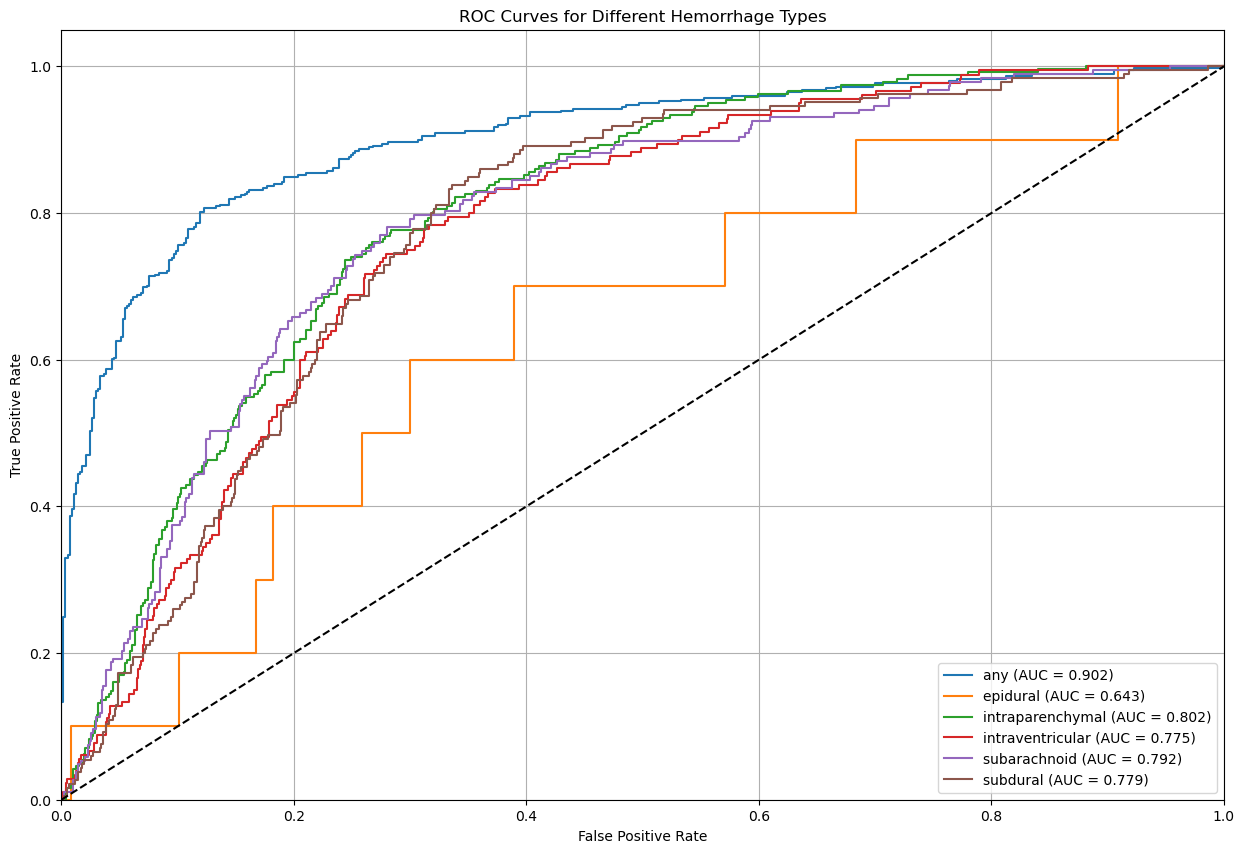

In [39]:
# Calculate predictions and metrics for each model
metrics_dict = {}
plt.figure(figsize=(15, 10))

for i, (model, col) in enumerate(zip(svm_models, target_columns)):
    # Get predictions and probabilities
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test[:, i], y_pred)
    precision = precision_score(y_test[:, i], y_pred)
    recall = recall_score(y_test[:, i], y_pred)
    f1 = f1_score(y_test[:, i], y_pred)
    
    # Store metrics
    metrics_dict[col] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    
    # Calculate ROC curve
    if hasattr(model, 'decision_function'):
        # For SVM, we use decision_function
        y_scores = model.decision_function(X_test_scaled)
    else:
        # For other models that might use predict_proba
        y_scores = model.predict_proba(X_test_scaled)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test[:, i], y_scores)
    roc_auc = auc(fpr, tpr)
    metrics_dict[col]['AUC'] = roc_auc
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{col} (AUC = {roc_auc:.3f})')

# Finalize and display the ROC plot
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Hemorrhage Types')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [40]:
# Create a DataFrame with all metrics
metrics_df = pd.DataFrame.from_dict(metrics_dict, orient='index')

# Format the metrics to percentage with 2 decimal places
metrics_df = metrics_df.apply(lambda x: round(x * 100, 2))

# Add % symbol to all values
metrics_df = metrics_df.astype(str) + '%'

# Display the formatted metrics
print("\nDetailed Model Performance Metrics:")
print("===================================")
print(metrics_df.to_string())

# Calculate and display mean metrics
mean_metrics = metrics_df.apply(lambda x: pd.to_numeric(x.str.rstrip('%'))).mean()
print("\nMean Metrics Across All Hemorrhage Types:")
print("=====================================")
for metric, value in mean_metrics.items():
    print(f"{metric}: {value:.2f}%")


Detailed Model Performance Metrics:
                 Accuracy Precision  Recall F1-Score     AUC
any                84.71%    81.89%  80.65%   81.27%  90.23%
epidural            97.0%     4.76%   10.0%    6.45%   64.3%
intraparenchymal   73.66%    48.29%  76.03%   59.07%  80.16%
intraventricular   69.32%    35.34%  78.33%    48.7%  77.55%
subarachnoid       71.18%    38.21%  79.68%   51.65%  79.18%
subdural           71.07%    37.33%  75.68%    50.0%  77.92%

Mean Metrics Across All Hemorrhage Types:
Accuracy: 77.82%
Precision: 40.97%
Recall: 66.73%
F1-Score: 49.52%
AUC: 78.22%
